**Mount Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Paths**

In [2]:
dataset_path = "/content/drive/MyDrive/DL Project/Water Turbidity"

train_path = dataset_path + "/train"
valid_path = dataset_path + "/valid"
test_path  = dataset_path + "/test"

print("Train Path:", train_path)

Train Path: /content/drive/MyDrive/DL Project/Water Turbidity/train


**Imports**

In [3]:
import os
import numpy as np
import pandas as pd
import cv2
import random
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import TimeDistributed, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

**Parameters**

In [4]:
IMG_SIZE = 128
SEQUENCE_LENGTH = 4   # frames per sequence

In [5]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

**Turbidity Severity Mapping**

In [6]:
severity_order = {
    "NTU-1": 0,
    "Around_30_NTU": 1,
    "Around_90_NTU": 2,
    "Around_150_NTU": 3
}

**Load Images + Severity**

In [7]:
def load_images_with_severity(folder):

    df = pd.read_csv(os.path.join(folder, "_classes.csv"))

    images = []
    labels = []
    severity = []

    for _, row in df.iterrows():

        img_name = row['filename']
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img_to_array(img) / 255.0

        # Get class label
        label = row[1:].idxmax()

        # FIX — Remove spaces
        label = label.strip()

        images.append(img)
        labels.append(label)

        # Map severity
        severity.append(severity_order[label])

    return np.array(images), np.array(labels), np.array(severity)

**Load Dataset**

In [8]:
X_train, y_train_raw, sev_train = load_images_with_severity(train_path)
X_valid, y_valid_raw, sev_valid = load_images_with_severity(valid_path)
X_test,  y_test_raw,  sev_test  = load_images_with_severity(test_path)

In [9]:
print("Train severity levels:", set(sev_train))

Train severity levels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3)}


**Sequence Creation Based on Severity**

In [10]:
def create_balanced_test_sequences(images, severity, seq_len, n_per_class=50):

    groups = {}
    for img, sev in zip(images, severity):
        groups.setdefault(sev, []).append(img)

    sev_levels = sorted(groups.keys())

    X_seq = []
    y_seq = []

    # -------- Increasing --------
    for _ in range(n_per_class):
        seq = []
        chosen = sorted(random.sample(sev_levels, seq_len))
        for s in chosen:
            seq.append(random.choice(groups[s]))
        X_seq.append(seq)
        y_seq.append("Increasing")

    # -------- Decreasing --------
    for _ in range(n_per_class):
        seq = []
        chosen = sorted(random.sample(sev_levels, seq_len), reverse=True)
        for s in chosen:
            seq.append(random.choice(groups[s]))
        X_seq.append(seq)
        y_seq.append("Decreasing")

    # -------- Stable --------
    for _ in range(n_per_class):
        s = random.choice(sev_levels)
        seq = random.choices(groups[s], k=seq_len)
        X_seq.append(seq)
        y_seq.append("Stable")

    return np.array(X_seq), np.array(y_seq)

**Generating Trend Sequence**

In [11]:
X_train_seq, y_train = create_balanced_test_sequences(
    X_train, sev_train, SEQUENCE_LENGTH
)

X_valid_seq, y_valid = create_balanced_test_sequences(
    X_valid, sev_valid, SEQUENCE_LENGTH
)

X_test_seq, y_test = create_balanced_test_sequences(
    X_test, sev_test, SEQUENCE_LENGTH, n_per_class=50
)

In [12]:
print("Train shape:", X_train_seq.shape)
print("Label distribution:", np.unique(y_train, return_counts=True))

Train shape: (150, 4, 128, 128, 3)
Label distribution: (array(['Decreasing', 'Increasing', 'Stable'], dtype='<U10'), array([50, 50, 50]))


**Encode Trend Labels**

In [13]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_valid = le.transform(y_valid)
y_test  = le.transform(y_test)

y_train = to_categorical(y_train)
y_valid = to_categorical(y_valid)
y_test  = to_categorical(y_test)

num_classes = y_train.shape[1]

print("Trend Classes:", le.classes_)

Trend Classes: ['Decreasing' 'Increasing' 'Stable']


**CNN-LSTM**

In [14]:
base_cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_cnn.trainable = False

model = Sequential()

model.add(TimeDistributed(base_cnn,
          input_shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)))

model.add(TimeDistributed(GlobalAveragePooling2D()))

model.add(LSTM(128,
               kernel_regularizer=l2(0.001)))

model.add(Dropout(0.6))

model.add(Dense(64,
                activation='relu',
                kernel_regularizer=l2(0.001)))

model.add(Dropout(0.4))

model.add(Dense(3, activation='softmax'))

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 4, 4, 4, 1280)  │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 4, 1280)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,987,843 (11.40 MB)

 Trainable params: 729,859 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Building Model**

In [15]:
model = Sequential()

model.add(TimeDistributed(base_cnn,
          input_shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)))

model.add(TimeDistributed(GlobalAveragePooling2D()))

model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(3, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, 4, 4, 4, 1280)  │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 4, 1280)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,987,843 (11.40 MB)

 Trainable params: 729,859 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Compile**

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', #multi class
    metrics=['accuracy']
)

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

**Train**

In [18]:
history = model.fit(
    X_train_seq,
    y_train,
    validation_data=(X_valid_seq, y_valid),
    epochs=40,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.4067 - loss: 1.0810 - val_accuracy: 0.4600 - val_loss: 1.0424
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5533 - loss: 0.9567 - val_accuracy: 0.4467 - val_loss: 0.9549
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6667 - loss: 0.8160 - val_accuracy: 0.3333 - val_loss: 0.9531
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6933 - loss: 0.6940 - val_accuracy: 0.5867 - val_loss: 0.8641
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7600 - loss: 0.6170 - val_accuracy: 0.8600 - val_loss: 0.6409
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7800 - loss: 0.5292 - val_accuracy: 0.5867 - val_loss: 0.6318
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7800 - loss: 0.5270 - val_accuracy: 0.7000 - val_loss: 0.6035
Epoch 8/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7933 - loss: 0.4706 - val_accuracy: 0.8267 - val_loss:

**Evaluate**

In [19]:
loss, acc = model.evaluate(X_test_seq, y_test)
print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 1.0000 - loss: 0.0055
Test Accuracy: 1.0


**Predict Trend**

In [20]:
pred = model.predict(X_test_seq)

pred_classes = le.inverse_transform(np.argmax(pred, axis=1))
actual_classes = le.inverse_transform(np.argmax(y_test, axis=1))

print("Predicted:", pred_classes[:15])
print("Actual:", actual_classes[:15])

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step
Predicted: ['Increasing' 'Increasing' 'Increasing' 'Increasing' 'Increasing'
 'Increasing' 'Increasing' 'Increasing' 'Increasing' 'Increasing'
 'Increasing' 'Increasing' 'Increasing' 'Increasing' 'Increasing']
Actual: ['Increasing' 'Increasing' 'Increasing' 'Increasing' 'Increasing'
 'Increasing' 'Increasing' 'Increasing' 'Increasing' 'Increasing'
 'Increasing' 'Increasing' 'Increasing' 'Increasing' 'Increasing']


**Predicted vs Actual for all 150 samples**

In [21]:
for i in range(len(pred_classes)):
    print(f"Sample {i+1}:")
    print("Predicted:", pred_classes[i])
    print("Actual   :", actual_classes[i])
    print("----------")

Sample 1:
Predicted: Increasing
Actual   : Increasing
----------
Sample 2:
Predicted: Increasing
Actual   : Increasing
----------
Sample 3:
Predicted: Increasing
Actual   : Increasing
----------
Sample 4:
Predicted: Increasing
Actual   : Increasing
----------
Sample 5:
Predicted: Increasing
Actual   : Increasing
----------
Sample 6:
Predicted: Increasing
Actual   : Increasing
----------
Sample 7:
Predicted: Increasing
Actual   : Increasing
----------
Sample 8:
Predicted: Increasing
Actual   : Increasing
----------
Sample 9:
Predicted: Increasing
Actual   : Increasing
----------
Sample 10:
Predicted: Increasing
Actual   : Increasing
----------
Sample 11:
Predicted: Increasing
Actual   : Increasing
----------
Sample 12:
Predicted: Increasing
Actual   : Increasing
----------
Sample 13:
Predicted: Increasing
Actual   : Increasing
----------
Sample 14:
Predicted: Increasing
Actual   : Increasing
----------
Sample 15:
Predicted: Increasing
Actual   : Increasing
----------
Sample 16:
Predicte

In [22]:
pred_classes = le.inverse_transform(np.argmax(pred, axis=1))
actual_classes = le.inverse_transform(np.argmax(y_test, axis=1))

**Accuracy Summary and Confusion Matrix**

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(actual_classes, pred_classes))

cm = confusion_matrix(actual_classes, pred_classes)
print("Confusion Matrix:\n", cm)

              precision    recall  f1-score   support

  Decreasing       1.00      1.00      1.00        50
  Increasing       1.00      1.00      1.00        50
      Stable       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150

Confusion Matrix:
 [[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]


**Image Sequence Display**

In [24]:
def show_sequence(sequence, label):
    plt.figure(figsize=(12,3))

    for i in range(len(sequence)):
        plt.subplot(1, len(sequence), i+1)
        plt.imshow(sequence[i])
        plt.axis('off')
        plt.title(f"Frame {i+1}")

    plt.suptitle(f"Trend: {label}", fontsize=14)
    plt.show()

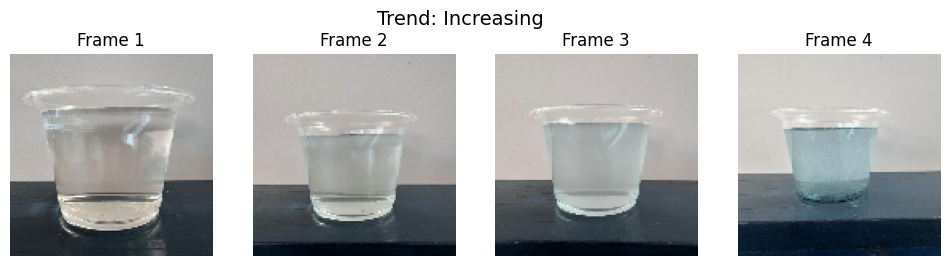

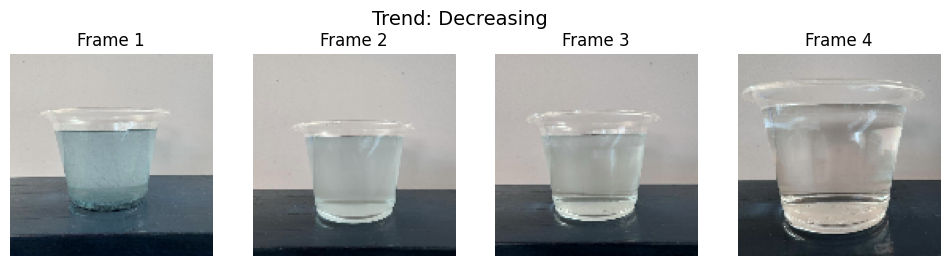

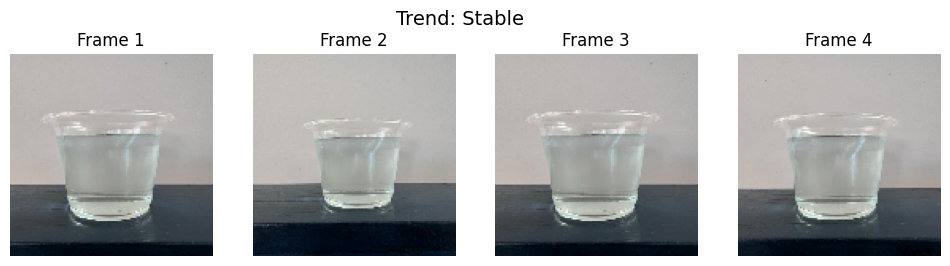

In [25]:
labels = le.inverse_transform(np.argmax(y_test, axis=1))

shown = {"Increasing": False, "Decreasing": False, "Stable": False}

for i in range(len(X_test_seq)):
    label = labels[i]

    if not shown[label]:
        show_sequence(X_test_seq[i], label)
        shown[label] = True

    if all(shown.values()):
        break

**DYNAMIC SEQUENCE VIEWER**

In [26]:
def view_sequence(sample_index):

    # Get prediction
    pred = model.predict(X_test_seq[sample_index:sample_index+1])

    predicted_label = le.inverse_transform(
        [np.argmax(pred)]
    )[0]

    actual_label = le.inverse_transform(
        [np.argmax(y_test[sample_index])]
    )[0]

    # Plot images
    plt.figure(figsize=(12,3))

    for i in range(len(X_test_seq[sample_index])):
        plt.subplot(1, len(X_test_seq[sample_index]), i+1)
        plt.imshow(X_test_seq[sample_index][i])
        plt.axis('off')
        plt.title(f"Frame {i+1}")

    plt.suptitle(
        f"Sample {sample_index} | Predicted: {predicted_label} | Actual: {actual_label}",
        fontsize=14
    )

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


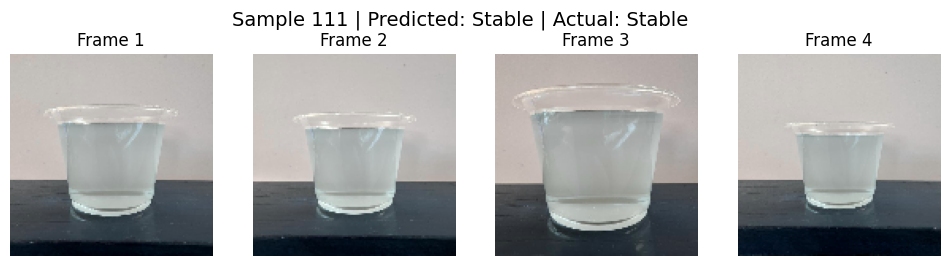

In [35]:
view_sequence(111)

**VISUALIZATION :** Training vs Validation Accuracy

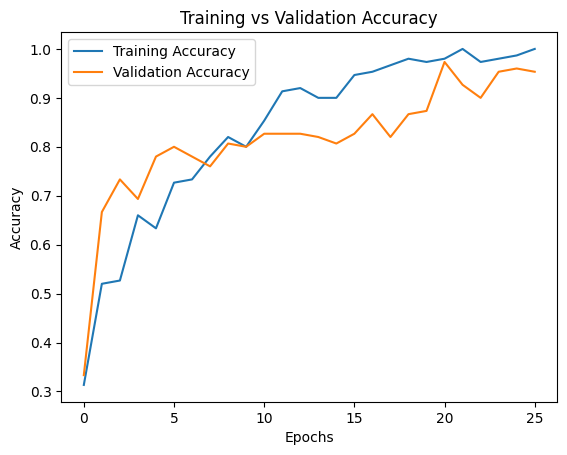

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

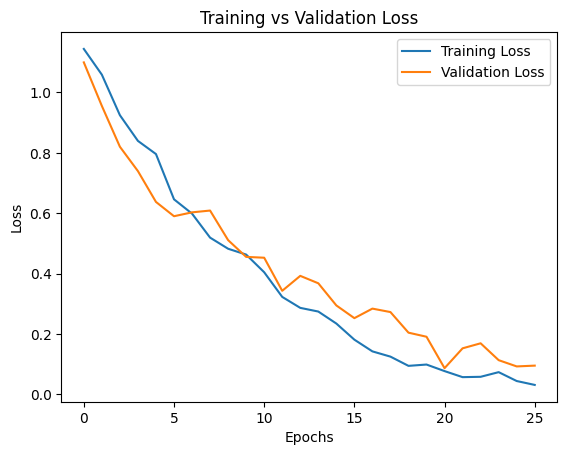

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

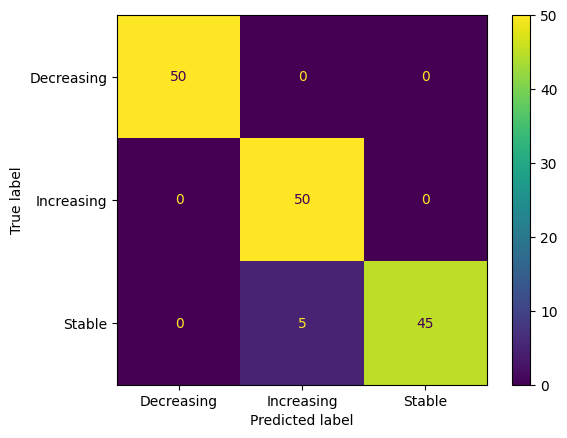

In [ ]:
cm = confusion_matrix(actual_classes, pred_classes)

disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot()